# Player & Team Opponent Matchup Recommender





### Load Data

In [52]:
from pyspark.sql import SparkSession
from pyspark.sql import Window
from pyspark.ml.feature import VectorAssembler, StandardScaler

import pandas as pd
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import numpy as np

# Create Spark session if needed
try:
    spark
except NameError:
    spark = (
        SparkSession.builder
        .appName("PlayerTeamOpponentMatchupRecommender")
        .getOrCreate()
    )

spark



In [79]:
# Read all files in the Pig output folder (no header)
joined_raw = spark.read.option("header", False).csv("file:/lab/outputs/team_joined")


print(f"Number of columns: {len(joined_raw.columns)}")
#joined_raw.show(3, truncate=False)



Number of columns: 59


### Assign Col Names

In [54]:
player_cols = [
    "p_gameid", "p_date", "p_type", "p_playerid", "p_player",
    "p_team", "p_home", "p_away",
    "p_MIN", "p_PTS", "p_FGM", "p_FGA", "p_FG_PCT",
    "p_TPM", "p_TPA", "p_TP_PCT",
    "p_FTM", "p_FTA", "p_FT_PCT",
    "p_OREB", "p_DREB", "p_REB",
    "p_AST", "p_STL", "p_BLK", "p_TOV", "p_PF",
    "p_PLUS_MINUS", "p_win", "p_season"
]

team_cols = [
    "t_gameid", "t_date", "t_type", "t_teamid", "t_team",
    "t_home", "t_away",
    "t_MIN", "t_PTS", "t_FGM", "t_FGA", "t_FG_PCT",
    "t_TPM", "t_TPA", "t_TP_PCT",
    "t_FTM", "t_FTA", "t_FT_PCT",
    "t_OREB", "t_DREB", "t_REB",
    "t_AST", "t_STL", "t_BLK", "t_TOV", "t_PF",
    "t_PLUS_MINUS", "t_win", "t_season"
]

all_cols = player_cols + team_cols

joined = joined_raw.toDF(*all_cols)

#joined.select(
#    "p_gameid", "p_player", "p_team", "p_PTS",
#    "t_team", "t_PTS", "t_home", "t_away"
#).show(5, truncate=False)


+--------+----------------+------+-----+------+-----+------+------+
|p_gameid|p_player        |p_team|p_PTS|t_team|t_PTS|t_home|t_away|
+--------+----------------+------+-----+------+-----+------+------+
|29600001|Dana Barros     |BOS   |24   |BOS   |98   |BOS   |CHI   |
|29600001|Pervis Ellison  |BOS   |7    |BOS   |98   |BOS   |CHI   |
|29600001|Frank Brickowski|BOS   |3    |BOS   |98   |BOS   |CHI   |
|29600001|Eric Williams   |BOS   |14   |BOS   |98   |BOS   |CHI   |
|29600001|Brett Szabo     |BOS   |0    |BOS   |98   |BOS   |CHI   |
+--------+----------------+------+-----+------+-----+------+------+
only showing top 5 rows


In [55]:
int_cols = [
    "p_playerid",
    "p_MIN", "p_PTS", "p_FGM", "p_FGA",
    "p_TPM", "p_TPA",
    "p_FTM", "p_FTA",
    "p_OREB", "p_DREB", "p_REB",
    "p_AST", "p_STL", "p_BLK", "p_TOV", "p_PF",
    "p_PLUS_MINUS", "p_win", "p_season",
    "t_teamid",
    "t_MIN", "t_PTS", "t_FGM", "t_FGA",
    "t_TPM", "t_TPA",
    "t_FTM", "t_FTA",
    "t_OREB", "t_DREB", "t_REB",
    "t_AST", "t_STL", "t_BLK", "t_TOV", "t_PF",
    "t_PLUS_MINUS", "t_win", "t_season"
]

float_cols = [
    "p_FG_PCT", "p_TP_PCT", "p_FT_PCT",
    "t_FG_PCT", "t_TP_PCT", "t_FT_PCT"
]

for c in int_cols:
    joined = joined.withColumn(c, F.col(c).cast("int"))

for c in float_cols:
    joined = joined.withColumn(c, F.col(c).cast("double"))

#joined.printSchema()


root
 |-- p_gameid: string (nullable = true)
 |-- p_date: string (nullable = true)
 |-- p_type: string (nullable = true)
 |-- p_playerid: integer (nullable = true)
 |-- p_player: string (nullable = true)
 |-- p_team: string (nullable = true)
 |-- p_home: string (nullable = true)
 |-- p_away: string (nullable = true)
 |-- p_MIN: integer (nullable = true)
 |-- p_PTS: integer (nullable = true)
 |-- p_FGM: integer (nullable = true)
 |-- p_FGA: integer (nullable = true)
 |-- p_FG_PCT: double (nullable = true)
 |-- p_TPM: integer (nullable = true)
 |-- p_TPA: integer (nullable = true)
 |-- p_TP_PCT: double (nullable = true)
 |-- p_FTM: integer (nullable = true)
 |-- p_FTA: integer (nullable = true)
 |-- p_FT_PCT: double (nullable = true)
 |-- p_OREB: integer (nullable = true)
 |-- p_DREB: integer (nullable = true)
 |-- p_REB: integer (nullable = true)
 |-- p_AST: integer (nullable = true)
 |-- p_STL: integer (nullable = true)
 |-- p_BLK: integer (nullable = true)
 |-- p_TOV: integer (nullabl

In [56]:
joined = joined.withColumn(
    "opponent_team",
    F.when(F.col("p_team") == F.col("t_home"), F.col("t_away"))
     .otherwise(F.col("t_home"))
)

joined.select(
    "p_gameid", "p_player", "p_team", "opponent_team",
    "t_team", "t_home", "t_away", "t_PTS"
).show(10, truncate=False)


+--------+----------------+------+-------------+------+------+------+-----+
|p_gameid|p_player        |p_team|opponent_team|t_team|t_home|t_away|t_PTS|
+--------+----------------+------+-------------+------+------+------+-----+
|29600001|Dana Barros     |BOS   |CHI          |BOS   |BOS   |CHI   |98   |
|29600001|Pervis Ellison  |BOS   |CHI          |BOS   |BOS   |CHI   |98   |
|29600001|Frank Brickowski|BOS   |CHI          |BOS   |BOS   |CHI   |98   |
|29600001|Eric Williams   |BOS   |CHI          |BOS   |BOS   |CHI   |98   |
|29600001|Brett Szabo     |BOS   |CHI          |BOS   |BOS   |CHI   |98   |
|29600001|Antoine Walker  |BOS   |CHI          |BOS   |BOS   |CHI   |98   |
|29600001|Rick Fox        |BOS   |CHI          |BOS   |BOS   |CHI   |98   |
|29600001|Todd Day        |BOS   |CHI          |BOS   |BOS   |CHI   |98   |
|29600001|David Wesley    |BOS   |CHI          |BOS   |BOS   |CHI   |98   |
|29600001|Luc Longley     |CHI   |BOS          |CHI   |BOS   |CHI   |107  |
+--------+--

In [57]:
team_games = (
    joined
      .select(
          "t_gameid", "t_teamid", "t_team",
          "t_home", "t_away",
          "t_PTS", "t_win", "t_season"
      )
      .dropDuplicates(["t_gameid", "t_teamid"])
      .withColumnRenamed("t_gameid", "gameid")
      .withColumnRenamed("t_team", "team")
      .withColumnRenamed("t_teamid", "teamid")
      .withColumnRenamed("t_home", "home")
      .withColumnRenamed("t_away", "away")
      .withColumnRenamed("t_PTS", "PTS")
      .withColumnRenamed("t_win", "win")
      .withColumnRenamed("t_season", "season")
)

team_games.show(10, truncate=False)


+--------+----------+----+----+----+---+---+------+
|gameid  |teamid    |team|home|away|PTS|win|season|
+--------+----------+----+----+----+---+---+------+
|29600001|1610612738|BOS |BOS |CHI |98 |0  |1997  |
|29600001|1610612741|CHI |BOS |CHI |107|1  |1997  |
|29600002|1610612739|CLE |NJN |CLE |90 |1  |1997  |
|29600002|1610612751|NJN |NJN |CLE |77 |0  |1997  |
|29600003|1610612749|MIL |PHI |MIL |111|1  |1997  |
|29600003|1610612755|PHI |PHI |MIL |103|0  |1997  |
|29600004|1610612753|ORL |ORL |WAS |92 |0  |1997  |
|29600004|1610612764|WAS |ORL |WAS |96 |1  |1997  |
|29600005|1610612737|ATL |MIA |ATL |81 |0  |1997  |
|29600005|1610612748|MIA |MIA |ATL |94 |1  |1997  |
+--------+----------+----+----+----+---+---+------+
only showing top 10 rows


### Build Team vs Opp Matchups 

In [58]:
a = team_games.alias("a")
b = team_games.alias("b")

team_matchups = (
    a.join(
        b,
        (F.col("a.gameid") == F.col("b.gameid")) &
        (F.col("a.team") != F.col("b.team")),
        "inner"
    )
    .select(
        F.col("a.gameid").alias("gameid"),
        F.col("a.team").alias("team"),
        F.col("b.team").alias("opponent"),
        F.col("a.PTS").alias("team_pts"),
        F.col("b.PTS").alias("opp_pts"),
        (F.col("a.PTS") - F.col("b.PTS")).alias("point_diff"),
        F.col("a.win").alias("team_win"),
        F.col("a.season").alias("season")
    )
)

team_matchups.show(10, truncate=False)


+--------+----+--------+--------+-------+----------+--------+------+
|gameid  |team|opponent|team_pts|opp_pts|point_diff|team_win|season|
+--------+----+--------+--------+-------+----------+--------+------+
|29600001|BOS |CHI     |98      |107    |-9        |0       |1997  |
|29600001|CHI |BOS     |107     |98     |9         |1       |1997  |
|29600002|CLE |NJN     |90      |77     |13        |1       |1997  |
|29600002|NJN |CLE     |77      |90     |-13       |0       |1997  |
|29600003|MIL |PHI     |111     |103    |8         |1       |1997  |
|29600003|PHI |MIL     |103     |111    |-8        |0       |1997  |
|29600004|ORL |WAS     |92      |96     |-4        |0       |1997  |
|29600004|WAS |ORL     |96      |92     |4         |1       |1997  |
|29600005|ATL |MIA     |81      |94     |-13       |0       |1997  |
|29600005|MIA |ATL     |94      |81     |13        |1       |1997  |
+--------+----+--------+--------+-------+----------+--------+------+
only showing top 10 rows


### Aggregate Team vs Opp Stats 

In [59]:
team_opp_stats = (
    team_matchups
      .groupBy("team", "opponent")
      .agg(
          F.count("*").alias("games_played"),
          F.avg("point_diff").alias("avg_point_diff"),
          F.avg(F.col("team_win").cast("double")).alias("win_rate")
      )
)

team_opp_stats.orderBy("team", "opponent").show(5, truncate=False)


+----+--------+------------+------------------+------------------+
|team|opponent|games_played|avg_point_diff    |win_rate          |
+----+--------+------------+------------------+------------------+
|ATL |BOS     |12          |5.333333333333333 |0.75              |
|ATL |CHH     |17          |5.0588235294117645|0.5882352941176471|
|ATL |CHI     |18          |-3.0              |0.3888888888888889|
|ATL |CLE     |13          |5.076923076923077 |0.7692307692307693|
|ATL |DAL     |5           |22.4              |0.8               |
+----+--------+------------+------------------+------------------+
only showing top 5 rows


### Pivot Table 

In [80]:
team_pivot = (
    team_opp_stats
      .groupBy("team")
      .pivot("opponent")
      .avg("avg_point_diff")
)

team_pivot = team_pivot.fillna(0.0)

#team_pivot.show(5, truncate=False)


### Best Matchups

In [61]:
opp_cols = [c for c in team_pivot.columns if c != "team"]

team_pivot_long = team_pivot.select(
    "team",
    F.explode(
        F.map_from_arrays(
            F.array(*[F.lit(c) for c in opp_cols]),
            F.array(*[F.col(c) for c in opp_cols])
        )
    ).alias("opponent", "pivot_point_diff")
)

w_team = Window.partitionBy("team").orderBy(F.col("pivot_point_diff").desc())

team_matchup_ranked = team_pivot_long.withColumn("rank", F.row_number().over(w_team))

TOP_K = 5

team_best_matchups = (
    team_matchup_ranked
      .filter(F.col("rank") <= TOP_K)
      .join(team_opp_stats, on=["team", "opponent"], how="left")
      .select(
          "team", "opponent", "rank",
          "pivot_point_diff",
          "avg_point_diff",
          "win_rate",
          "games_played"
      )
      .orderBy("team", "rank")
)

team_best_matchups.show(10, truncate=False)


+----+--------+----+------------------+------------------+------------------+------------+
|team|opponent|rank|pivot_point_diff  |avg_point_diff    |win_rate          |games_played|
+----+--------+----+------------------+------------------+------------------+------------+
|ATL |DAL     |1   |22.4              |22.4              |0.8               |5           |
|ATL |LAC     |2   |15.5              |15.5              |1.0               |6           |
|ATL |VAN     |3   |13.0              |13.0              |0.8333333333333334|6           |
|ATL |TOR     |4   |11.666666666666666|11.666666666666666|0.9166666666666666|12          |
|ATL |GSW     |5   |10.6              |10.6              |0.8               |5           |
|BOS |LAC     |1   |5.833333333333333 |5.833333333333333 |0.5               |6           |
|BOS |DEN     |2   |5.0               |5.0               |0.6666666666666666|6           |
|BOS |DAL     |3   |4.25              |4.25              |0.5               |4           |

In [62]:
team_profile = (
    joined
      .groupBy("p_team")
      .agg(
          F.avg("t_PTS").alias("avg_pts"),
          F.avg("t_FGM").alias("avg_fgm"),
          F.avg("t_FGA").alias("avg_fga"),
          F.avg("t_TPM").alias("avg_tpm"),
          F.avg("t_TPA").alias("avg_tpa"),
          F.avg("t_FT_PCT").alias("avg_ft_pct"),
          F.avg("t_AST").alias("avg_ast"),
          F.avg("t_OREB").alias("avg_oreb"),
          F.avg("t_DREB").alias("avg_dreb"),
          F.avg("t_STL").alias("avg_stl"),
          F.avg("t_BLK").alias("avg_blk"),
          F.avg("t_TOV").alias("avg_tov")
      )
      .withColumnRenamed("p_team", "team")
)

#team_profile.show(5, truncate=False)



+----+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+-----------------+------------------+
|team|avg_pts           |avg_fgm           |avg_fga          |avg_tpm           |avg_tpa           |avg_ft_pct       |avg_ast           |avg_oreb          |avg_dreb          |avg_stl           |avg_blk          |avg_tov           |
+----+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+-----------------+------------------+
|GSW |92.61874503574265 |35.526211278792694|83.26767275615568|3.911040508339952 |12.35782366957903 |71.89360603653691|21.476171564733917|15.149324861000794|29.40111199364575 |16.39952343129468 |7.727164416203336|4.7192216044479744|
|DET |94.14460596786535 |34.592960979342   |76.39326702371844|5.12777352

In [63]:
profile_features = [
    "avg_pts", "avg_fgm", "avg_fga", "avg_tpm", "avg_tpa",
    "avg_ft_pct", "avg_ast", "avg_oreb", "avg_dreb",
    "avg_stl", "avg_blk", "avg_tov"
]

assembler_profile = VectorAssembler(
    inputCols=profile_features,
    outputCol="profile_features_vec"
)

team_profile_vec = assembler_profile.transform(team_profile)

scaler = StandardScaler(
    inputCol="profile_features_vec",
    outputCol="profile_scaled",
    withMean=True,
    withStd=True
)

profile_model = scaler.fit(team_profile_vec)
team_profile_scaled = profile_model.transform(team_profile_vec)

team_profile_scaled.show(5, truncate=False)


+----+------------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+-----------------+------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|team|avg_pts           |avg_fgm           |avg_fga          |avg_tpm           |avg_tpa           |avg_ft_pct       |avg_ast           |avg_oreb          |avg_dreb          |avg_stl           |avg_blk          |avg_tov           |profile_features_vec                                                    

In [64]:
opp_cols = [c for c in team_pivot.columns if c != "team"]

assembler_cf = VectorAssembler(
    inputCols=opp_cols,
    outputCol="cf_vec"
)

team_cf_vec = assembler_cf.transform(team_pivot)

scaler_cf = StandardScaler(
    inputCol="cf_vec",
    outputCol="cf_scaled",
    withMean=True,
    withStd=True
)

cf_model = scaler_cf.fit(team_cf_vec)
team_cf_scaled = cf_model.transform(team_cf_vec)

#team_cf_scaled.show(5, truncate=False)


+----+-------------------+-----------------+-------------------+-------------------+-------------------+------------------+------------------+--------------------+-----------------+------------------+-------------------+------------------+-----+------------------+------------------+-----------------+------------------+------------------+-------------------+------------------+-------------------+-------------------+------------------+-------------------+-------------------+------------------+-------------------+------------------+------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------

In [65]:
def cosine_sim(a, b):
    a = np.array(a)
    b = np.array(b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return float(np.dot(a, b) / (norm_a * norm_b))

cosine_sim_udf = F.udf(cosine_sim, "double")


In [66]:
cf_a = team_cf_scaled.alias("a")
cf_b = team_cf_scaled.alias("b")

team_cf_similarity = (
    cf_a.crossJoin(cf_b)
        .where(F.col("a.team") != F.col("b.team"))
        .select(
            F.col("a.team").alias("team"),
            F.col("b.team").alias("similar_team"),
            cosine_sim_udf("a.cf_scaled", "b.cf_scaled").alias("cf_similarity")
        )
)


In [67]:
cb_a = team_profile_scaled.alias("a")
cb_b = team_profile_scaled.alias("b")

team_cb_similarity = (
    cb_a.crossJoin(cb_b)
        .where(F.col("a.team") != F.col("b.team"))
        .select(
            F.col("a.team").alias("team"),
            F.col("b.team").alias("similar_team"),
            cosine_sim_udf("a.profile_scaled", "b.profile_scaled").alias("cb_similarity")
        )
)


In [68]:
team_hybrid_similarity = (
    team_cf_similarity.alias("cf")
      .join(team_cb_similarity.alias("cb"),
            on=["team", "similar_team"],
            how="inner")
      .select(
          "team", "similar_team",
          "cf_similarity",
          "cb_similarity",
          (0.55 * F.col("cf_similarity") +
           0.45 * F.col("cb_similarity")).alias("hybrid_similarity")
      )
)


In [69]:
team_best_hybrid = (
    team_hybrid_similarity.alias("sim")
        .join(team_best_matchups.alias("bm"),
              F.col("sim.similar_team") == F.col("bm.team"), "inner")
        .select(
            F.col("sim.team").alias("team"),
            "opponent",
            "hybrid_similarity",
            "pivot_point_diff",
            "avg_point_diff",
            "win_rate",
            "games_played"
        )
        .orderBy("team", F.desc("hybrid_similarity"), F.desc("avg_point_diff"))
)


In [71]:
w = Window.partitionBy("team").orderBy(F.desc("hybrid_similarity"))

team_final_recommendations = (
    team_best_hybrid
        .withColumn("rank", F.row_number().over(w))
        .filter(F.col("rank") <= 5)
)

team_final_recommendations.show(5, truncate=False)


+----+--------+------------------+-----------------+-----------------+------------------+------------+----+
|team|opponent|hybrid_similarity |pivot_point_diff |avg_point_diff   |win_rate          |games_played|rank|
+----+--------+------------------+-----------------+-----------------+------------------+------------+----+
|ATL |GSW     |0.5373477822777721|23.2             |23.2             |1.0               |5           |1   |
|ATL |LAC     |0.5373477822777721|20.8             |20.8             |1.0               |5           |2   |
|ATL |DAL     |0.5373477822777721|12.4             |12.4             |1.0               |5           |3   |
|ATL |BOS     |0.5373477822777721|9.833333333333334|9.833333333333334|0.8333333333333334|12          |4   |
|ATL |DEN     |0.5373477822777721|9.2              |9.2              |0.8               |5           |5   |
+----+--------+------------------+-----------------+-----------------+------------------+------------+----+
only showing top 5 rows


## Visualisations

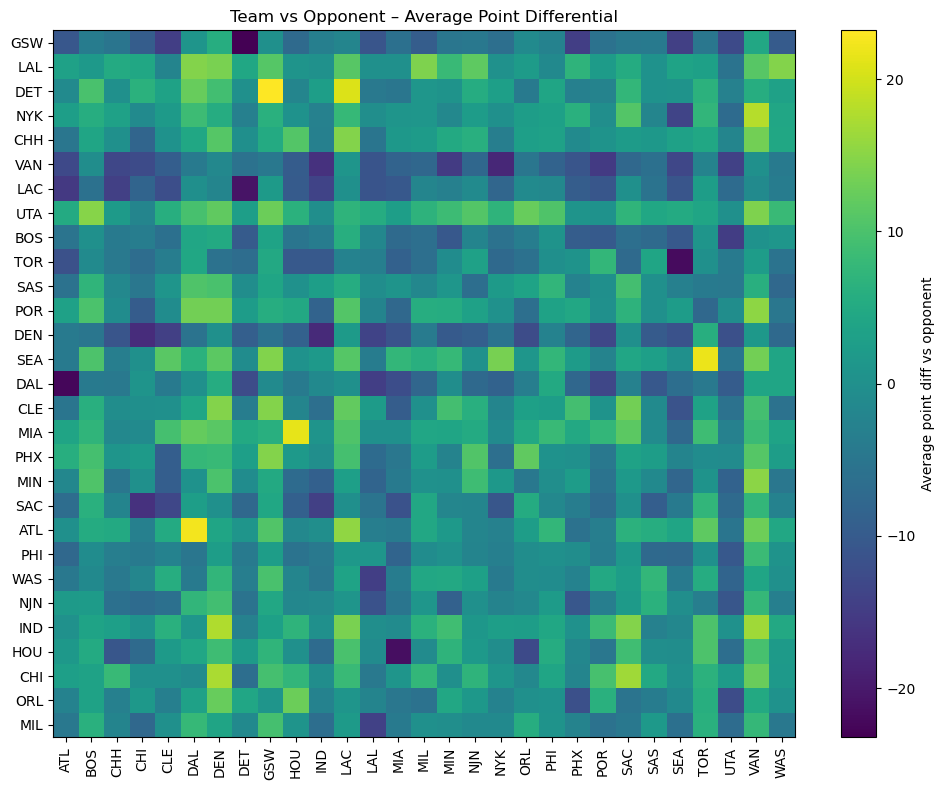

In [72]:
team_pivot_pd = team_pivot.toPandas().set_index("team")

plt.figure(figsize=(10, 8))
plt.imshow(team_pivot_pd, aspect="auto")
plt.colorbar(label="Average point diff vs opponent")
plt.xticks(range(len(team_pivot_pd.columns)), team_pivot_pd.columns, rotation=90)
plt.yticks(range(len(team_pivot_pd.index)), team_pivot_pd.index)
plt.title("Team vs Opponent – Average Point Differential")
plt.tight_layout()
plt.show()



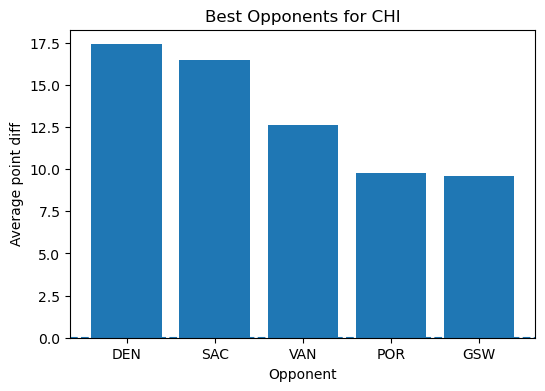

In [73]:
team = "CHI"  # pick a team you care about

chi_best = (team_best_matchups
            .filter(F.col("team") == team)
            .orderBy("rank"))

chi_best_pd = chi_best.toPandas()

plt.figure(figsize=(6,4))
plt.bar(chi_best_pd["opponent"], chi_best_pd["avg_point_diff"])
plt.axhline(0, linestyle="--")
plt.title(f"Best Opponents for {team}")
plt.ylabel("Average point diff")
plt.xlabel("Opponent")
plt.show()


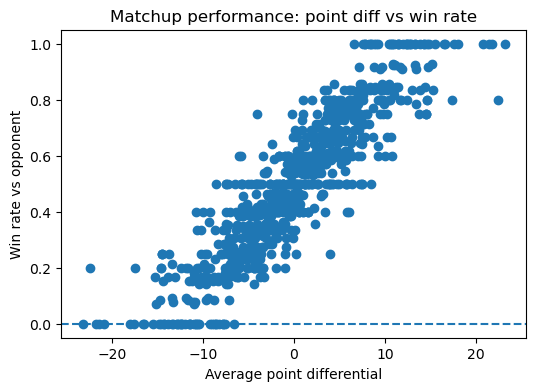

In [74]:
stats_pd = team_opp_stats.toPandas()

plt.figure(figsize=(6,4))
plt.scatter(stats_pd["avg_point_diff"], stats_pd["win_rate"])
plt.axhline(0, linestyle="--")
plt.title("Matchup performance: point diff vs win rate")
plt.xlabel("Average point differential")
plt.ylabel("Win rate vs opponent")
plt.show()


## Player vs Team Analysis 

In [75]:
player_opp_stats = (
    joined
      .groupBy("p_playerid", "p_player", "p_team", "opponent_team")
      .agg(
          F.count("*").alias("games_vs_opp"),
          F.avg("p_PTS").alias("avg_pts_vs_opp"),
          F.avg("p_MIN").alias("avg_min_vs_opp"),
          F.avg("p_PLUS_MINUS").alias("avg_plusminus_vs_opp"),
          F.avg("p_FG_PCT").alias("avg_fg_pct_vs_opp")
      )
      .orderBy("p_player", "opponent_team")
)

player_opp_stats.show(20, truncate=False)


+----------+----------+------+-------------+------------+-----------------+------------------+--------------------+------------------+
|p_playerid|p_player  |p_team|opponent_team|games_vs_opp|avg_pts_vs_opp   |avg_min_vs_opp    |avg_plusminus_vs_opp|avg_fg_pct_vs_opp |
+----------+----------+------+-------------+------------+-----------------+------------------+--------------------+------------------+
|920       |A.C. Green|LAL   |ATL          |2           |6.0              |22.0              |13.5                |60.0              |
|920       |A.C. Green|DAL   |ATL          |4           |5.5              |25.75             |-10.5               |45.825            |
|920       |A.C. Green|DAL   |BOS          |3           |7.333333333333333|33.0              |-3.6666666666666665 |56.03333333333333 |
|920       |A.C. Green|LAL   |BOS          |1           |8.0              |28.0              |4.0                 |75.0              |
|920       |A.C. Green|DAL   |CHH          |4          

In [76]:
player_name = "Michael Jordan"   # change this to any player
player_df = player_opp_stats.filter(F.col("p_player") == player_name)

player_pd = player_df.toPandas().sort_values("avg_pts_vs_opp", ascending=False)
player_pd


,p_playerid,p_player,p_team,opponent_team,games_vs_opp,avg_pts_vs_opp,avg_min_vs_opp,avg_plusminus_vs_opp,avg_fg_pct_vs_opp
16,893,Michael Jordan,CHI,NYK,8,39.125000,41.875000,2.875000,50.912500
8,893,Michael Jordan,CHI,HOU,4,35.750000,40.000000,6.000000,48.325000
23,893,Michael Jordan,CHI,SEA,4,35.750000,42.750000,3.500000,48.000000
10,893,Michael Jordan,CHI,LAC,4,34.000000,41.500000,8.750000,45.400000
20,893,Michael Jordan,CHI,POR,4,33.750000,38.250000,8.000000,44.625000
25,893,Michael Jordan,CHI,UTA,16,33.375000,42.062500,2.812500,45.237500
27,893,Michael Jordan,CHI,WAS,10,32.700000,40.500000,6.000000,48.470000
21,893,Michael Jordan,CHI,SAC,4,32.000000,38.750000,14.500000,59.900000
2,893,Michael Jordan,CHI,CHH,13,31.615385,38.769231,12.153846,50.461538
12,893,Michael Jordan,CHI,MIA,12,31.583333,39.833333,4.833333,43.058333


### Visualisations

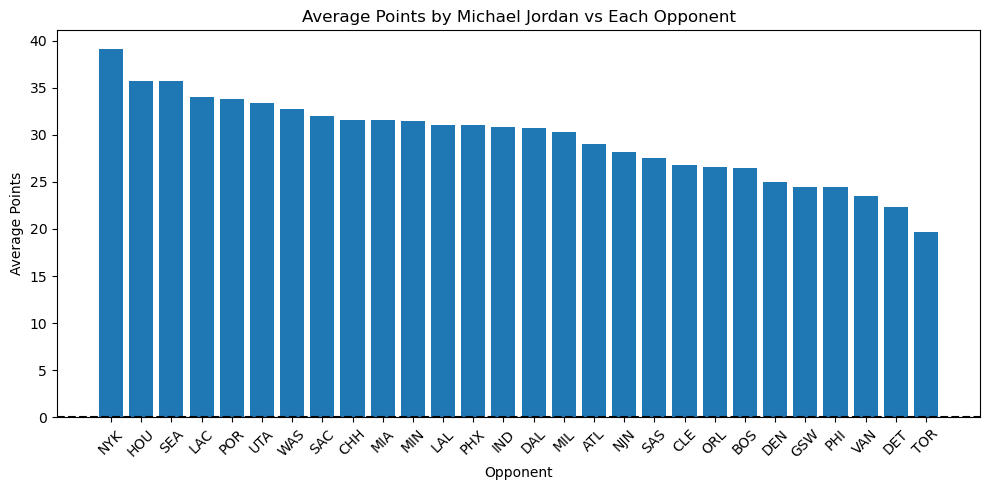

In [77]:
plt.figure(figsize=(10, 5))
plt.bar(player_pd["opponent_team"], player_pd["avg_pts_vs_opp"])
plt.xticks(rotation=45)
plt.title(f"Average Points by {player_name} vs Each Opponent")
plt.xlabel("Opponent")
plt.ylabel("Average Points")
plt.axhline(0, linestyle="--", color="black")
plt.tight_layout()
plt.show()


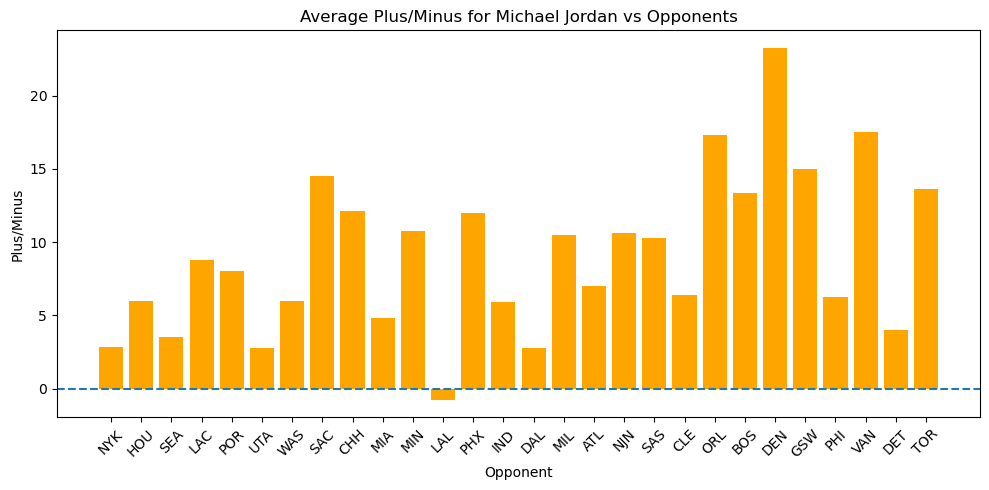

In [78]:
plt.figure(figsize=(10, 5))
plt.bar(player_pd["opponent_team"], player_pd["avg_plusminus_vs_opp"], color="orange")
plt.xticks(rotation=45)
plt.title(f"Average Plus/Minus for {player_name} vs Opponents")
plt.xlabel("Opponent")
plt.ylabel("Plus/Minus")
plt.axhline(0, linestyle="--")
plt.tight_layout()
plt.show()
